<a href="https://colab.research.google.com/github/araffin/rl-tutorial-jnrr19/blob/sb3/3_multiprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Baselines3 Tutorial - Multiprocessing of environments

Github repo: https://github.com/araffin/rl-tutorial-jnrr19/tree/sb3/

Stable-Baselines3: https://github.com/DLR-RM/stable-baselines3

Documentation: https://stable-baselines3.readthedocs.io/en/master/

SB3-Contrib: https://github.com/Stable-Baselines-Team/stable-baselines3-contrib

RL Baselines3 zoo: https://github.com/DLR-RM/rl-baselines3-zoo


## Introduction

In this notebook, you will learn how to use *Vectorized Environments* (aka multiprocessing) to make training faster. You will also see that this speed up comes at a cost of sample efficiency.

## Install Dependencies and Stable Baselines3 Using Pip

In [ ]:
# for autoformatting
# %load_ext jupyter_black

In [1]:
!apt install swig
!pip install "stable-baselines3[extra]>=2.0.0a4"

E: 无法打开锁文件 /var/lib/dpkg/lock-frontend - open (13: 权限不够)
E: 无法获取 dpkg 前端锁 (/var/lib/dpkg/lock-frontend)，请查看您是否正以 root 用户运行？


## Vectorized Environments and Imports

[Vectorized Environments](https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html) are a method for stacking multiple independent environments into a single environment. Instead of training an RL agent on 1 environment per step, it allows us to train it on n environments per step. This provides two benefits:
* Agent experience can be collected more quickly
* The experience will contain a more diverse range of states, it usually improves exploration

Stable-Baselines provides two types of Vectorized Environment:
- SubprocVecEnv which run each environment in a separate process
- DummyVecEnv which run all environment on the same process

In practice, DummyVecEnv is usually faster than SubprocVecEnv because of communication delays that subprocesses have.

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import gymnasium as gym

from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.utils import set_random_seed
from stable_baselines3 import PPO, A2C

Import evaluate function

In [3]:
from stable_baselines3.common.evaluation import evaluate_policy

## Define an environment function

The multiprocessing implementation requires a function that can be called inside the process to instantiate a gym env

In [4]:
def make_env(env_id, rank, seed=0):
    """
    Utility function for multiprocessed env.

    :param env_id: (str) the environment ID
    :param seed: (int) the inital seed for RNG
    :param rank: (int) index of the subprocess
    """

    def _init():
        env = gym.make(env_id)
        # use a seed for reproducibility
        # Important: use a different seed for each environment
        # otherwise they would generate the same experiences
        env.reset(seed=seed + rank)
        return env

    set_random_seed(seed)
    return _init

Stable-Baselines also provides directly an helper to create vectorized environment:

In [5]:
from stable_baselines3.common.env_util import make_vec_env

## Define a few constants (feel free to try out other environments and algorithms)
We will be using the Cartpole environment: [https://gym.openai.com/envs/CartPole-v1/](https://gym.openai.com/envs/CartPole-v1/)

![Cartpole](https://cdn-images-1.medium.com/max/1143/1*h4WTQNVIsvMXJTCpXm_TAw.gif)



In [6]:
env_id = "CartPole-v1"
# The different number of processes that will be used
PROCESSES_TO_TEST = [1, 2, 4, 8, 16]
NUM_EXPERIMENTS = 3  # RL algorithms can often be unstable, so we run several experiments (see https://arxiv.org/abs/1709.06560)
TRAIN_STEPS = 5000
# Number of episodes for evaluation
EVAL_EPS = 20
ALGO = A2C

# We will create one environment to evaluate the agent on
eval_env = gym.make(env_id)

## Iterate through the different numbers of processes

For each processes, several experiments are run per process
This may take a couple of minutes.

In [ ]:
"""
对不同并行环境数量（PROCESSES_TO_TEST 中的不同 n_procs）做多次独立实验（NUM_EXPERIMENTS），记录每次训练所需时间和评估平均奖励，最后把每组 n_procs 的平均奖励、奖励标准差与平均训练时间保存到 reward_averages、reward_std、training_times 中，以便比较并行度对训练速度与结果的影响。
"""
reward_averages = []
reward_std = []
training_times = []
total_procs = 0 # 累加器，用作后续 make_env(..., i + total_procs) 的偏移量，确保不同批次产生的子环境“编号/seed”不重合（常见用法是给每个子进程不同的 seed/rank）
for n_procs in PROCESSES_TO_TEST:
    total_procs += n_procs
    print(f"Running for n_procs = {n_procs}")

    if n_procs == 1:
        # if there is only one process, there is no need to use multiprocessing
        train_env = DummyVecEnv([lambda: gym.make(env_id)])
    else:
        # Here we use the "fork" method for launching the processes, more information is available in the doc
        # This is equivalent to make_vec_env(env_id, n_envs=n_procs, vec_env_cls=SubprocVecEnv, vec_env_kwargs=dict(start_method='fork'))
        train_env = SubprocVecEnv(
            [make_env(env_id, i + total_procs) for i in range(n_procs)], # i + total_procs 作为 seed 或 rank 传进去
            start_method="fork",# 用于 Linux 下的快速复制子进程方式。 Windows 下只能用 spawn
        )


    rewards = []
    times = []

    for experiment in range(NUM_EXPERIMENTS):
        # it is recommended to run several experiments due to variability in results
        # 对每个 n_procs 做 NUM_EXPERIMENTS 次独立重复试验（用于统计稳健性）。
        train_env.reset()
        model = ALGO("MlpPolicy", train_env, verbose=0)# 每次都重新创建一个模型实例（ALGO 代表像 PPO/A2C/SAC 等类）。这保证不同实验互相独立。

        start = time.time()
        model.learn(total_timesteps=TRAIN_STEPS)
        times.append(time.time() - start)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=EVAL_EPS) # 用单独的 eval_env（通常非并行、带 Monitor 的环境）评估训练好的模型若干 episode，返回平均奖励 mean_reward，存入 rewards 列表。
        rewards.append(mean_reward)
    # Important: when using subprocesses, don't forget to close them
    # otherwise, you may have memory issues when running a lot of experiments
    train_env.close() # 非常重要，释放子进程和资源。若不 close，会累积进程/内存泄漏。
    # 把该 n_procs 配置下多次实验的平均奖励、奖励标准差、平均训练时间分别追加到最终统计数组中。
    reward_averages.append(np.mean(rewards))
    reward_std.append(np.std(rewards))
    training_times.append(np.mean(times))

Running for n_procs = 1


/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Running for n_procs = 2
Running for n_procs = 4
Running for n_procs = 8
Running for n_procs = 16


## Plot the results

In [8]:
def plot_training_results(training_steps_per_second, reward_averages, reward_std):
    """
    Utility function for plotting the results of training

    :param training_steps_per_second: List[double]
    :param reward_averages: List[double]
    :param reward_std: List[double]
    """
    plt.figure(figsize=(9, 4))
    plt.subplots_adjust(wspace=0.5)
    plt.subplot(1, 2, 1)
    plt.errorbar(
        PROCESSES_TO_TEST,
        reward_averages,
        yerr=reward_std,
        capsize=2,
        c="k",
        marker="o",
    )
    plt.xlabel("Processes")
    plt.ylabel("Average return")
    plt.subplot(1, 2, 2)
    plt.bar(range(len(PROCESSES_TO_TEST)), training_steps_per_second)
    plt.xticks(range(len(PROCESSES_TO_TEST)), PROCESSES_TO_TEST)
    plt.xlabel("Processes")
    plt.ylabel("Training steps per second")

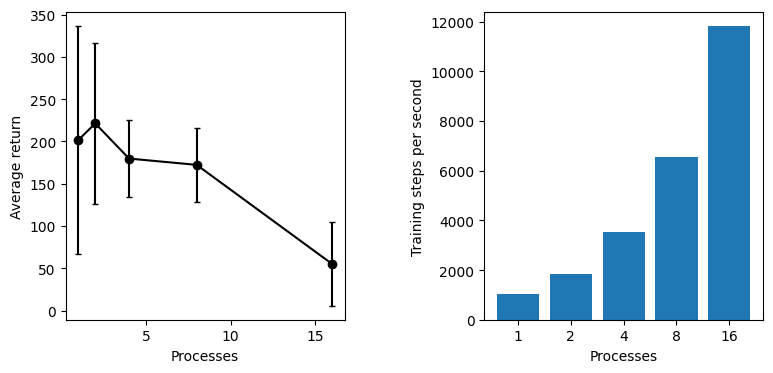

In [ ]:
training_steps_per_second = [TRAIN_STEPS / t for t in training_times]


plot_training_results(training_steps_per_second, reward_averages, reward_std)

# 少进程时，模型容易在特定场景中学得更高 reward，但泛化差；多进程时 reward 稍低，但更稳定。（每个进程的环境实例用的是不同的随机种子）

## Sample efficiency vs wall clock time trade-off
There is clearly a trade-off between sample efficiency, diverse experience and wall clock time. Let's try getting the best performance in a fixed amount of time, say 10 seconds per experiment

In [ ]:
"""
按不同并行环境数量 PROCESSES_TO_TEST，在每种配置下运行固定秒数的训练（通过 steps_per_experiment 把秒数转成 timesteps），做若干次重复实验，记录每次训练耗时与评估平均奖励，最后保存每种配置下的均值与标准差用于比较并行效率与性能。
"""
SECONDS_PER_EXPERIMENT = 10 # 每次实验跑多少秒
steps_per_experiment = [int(SECONDS_PER_EXPERIMENT * fps) for fps in training_steps_per_second] # 固定秒数*每秒步数（上一个实验中的）
reward_averages = []
reward_std = []
training_times = []

for n_procs, train_steps in zip(PROCESSES_TO_TEST, steps_per_experiment):
    total_procs += n_procs
    print(f"Running for n_procs = {n_procs} for steps = {train_steps}")
    if n_procs == 1:
        # if there is only one process, there is no need to use multiprocessing
        train_env = DummyVecEnv([lambda: gym.make(env_id)])
    else:
        train_env = SubprocVecEnv([make_env(env_id, i+total_procs) for i in range(n_procs)], start_method="spawn")
        # Alternatively, you can use a DummyVecEnv if the communication delays is the bottleneck
        # train_env = DummyVecEnv([make_env(env_id, i+total_procs) for i in range(n_procs)])

    rewards = []
    times = []

    for experiment in range(NUM_EXPERIMENTS):
        # it is recommended to run several experiments due to variability in results
        train_env.reset()
        model = ALGO("MlpPolicy", train_env, verbose=0)
        start = time.time()
        model.learn(total_timesteps=train_steps)
        times.append(time.time() - start)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=EVAL_EPS)
        rewards.append(mean_reward)

    train_env.close()
    reward_averages.append(np.mean(rewards))
    reward_std.append(np.std(rewards))
    training_times.append(np.mean(times))


Running for n_procs = 1 for steps = 10461


/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Running for n_procs = 2 for steps = 18443
Running for n_procs = 4 for steps = 35327
Running for n_procs = 8 for steps = 65499
Running for n_procs = 16 for steps = 118061


## Plot the results

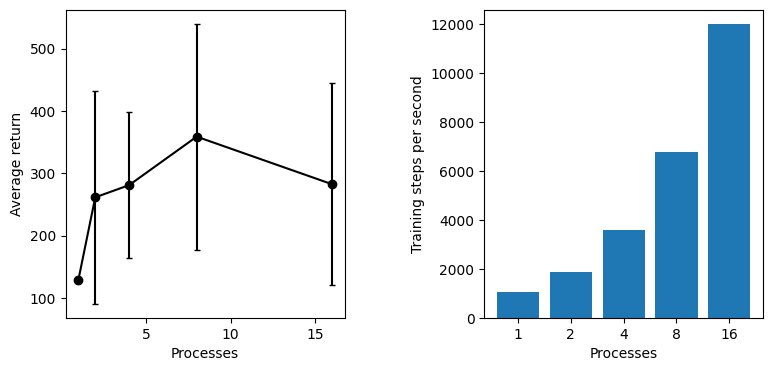

In [ ]:
training_steps_per_second = [s / t for s,t in zip(steps_per_experiment, training_times)]

plot_training_results(training_steps_per_second, reward_averages, reward_std)



### 第一个实验
不管开多少个进程（1、2、4、8...），每次实验都训练相同的总步数（5000）。

随着进程数增加，总的 wall-clock 时间会减少，因为多个环境在并行收集数据。

训练效果（奖励）：测试 reward 是否随并行数变化。理论上 reward 

因此：并行化提高训练效率，但不会影响策略表现

### 第二个实验
每个实验固定跑 10 秒，允许不同并行数的环境在这段时间里生成不同数量的训练步数。

并行数越多，固定时间内能收集到的经验越多，所以 reward 理论上更高（训练更“快”）

在相同 wall-clock 时间下，更多进程能 生成更多数据 → 提升策略表现


## DummyVecEnv vs SubprocVecEnv

In [ ]:
reward_averages = []
reward_std = []
training_times = []
total_procs = 0
for n_procs in PROCESSES_TO_TEST:
    total_procs += n_procs
    print(f'Running for n_procs = {n_procs}')
    # Here we are using only one process even for n_env > 1
    # this is equivalent to DummyVecEnv([make_env(env_id, i + total_procs) for i in range(n_procs)])
    train_env = make_vec_env(env_id, n_envs=n_procs) # make_vec_env 默认返回的是 DummyVecEnv（除非你指定 vec_env_cls=SubprocVecEnv）。
    # 单进程多环境（DummyVecEnv，伪并行）

    rewards = []
    times = []

    for experiment in range(NUM_EXPERIMENTS):
        # it is recommended to run several experiments due to variability in results
        train_env.reset()
        model = ALGO("MlpPolicy", train_env, verbose=0)
        start = time.time()
        model.learn(total_timesteps=TRAIN_STEPS)
        times.append(time.time() - start)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=EVAL_EPS)
        rewards.append(mean_reward)

    train_env.close()
    reward_averages.append(np.mean(rewards))
    reward_std.append(np.std(rewards))
    training_times.append(np.mean(times))

Running for n_procs = 1


/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/heshan/anaconda3/envs/gym310/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Running for n_procs = 2
Running for n_procs = 4
Running for n_procs = 8
Running for n_procs = 16


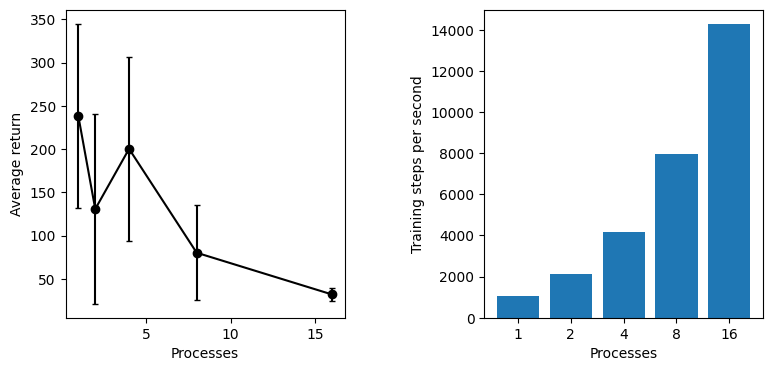

In [14]:
training_steps_per_second = [TRAIN_STEPS / t for t in training_times]

plot_training_results(training_steps_per_second, reward_averages, reward_std)

### What's happening?

It seems that having only one process for n environments is faster in our case.
In practice, the bottleneck does not come from the environment computation, but from synchronisation and communication between processes. To learn more about that problem, you can start [here](https://github.com/hill-a/stable-baselines/issues/322#issuecomment-492202915)

## Conclusions
This notebook has highlighted some of the pros and cons of multiprocessing. It is worth mentioning that colab notebooks only provide two CPU cores per process, so we do not see a linear scaling of the FPS of the environments. State of the art Deep RL research has scaled parallel processing to tens of thousands of CPU cores, [OpenAI RAPID](https://openai.com/blog/how-to-train-your-openai-five/) [IMPALA](https://arxiv.org/abs/1802.01561).

Do you think this direction of research is transferable to real world robots / intelligent agents?

Things to try:
* Another algorithm / environment.
* Increase the number of experiments.
* Train for more iterations.
